# <font color="steelblue">Máquinas de vector soporte lineales</font>

**Material desarrollado por los [equipos de trabajo de IA4LEGOS](https://ia4legos.umh.es/)**

**Fecha última edición**: 07/06/2026

**Licencia**: <a rel="license" href="http://creativecommons.org/licenses/by-sa/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-sa/4.0/88x31.png" /></a>

No olvides hacer una copia si deseas utilizarlo.

In [63]:
# @title Cargar configuración del cuaderno
!pip install gdown
!pip install --upgrade kagglehub
!pip install lightgbm xgboost
!pip install mlxtend --upgrade --no-deps
!pip install pingouin --upgrade
!pip install imbalanced-learn --upgrade

# Análisis numérico
import numpy as np
import pandas as pd
import math, random
import warnings
warnings.filterwarnings('ignore')

# Gráficos
import matplotlib.pyplot as plt
%matplotlib inline
from matplotlib.patches import Ellipse
import seaborn as sns
sns.set_theme(style='whitegrid')
%config InlineBackend.figure_format = 'retina'

import os, zipfile, gdown, kagglehub

# Funciones de preprocesado, evaluación, CP y auto_ML
from urllib.request import urlretrieve
for fichero in ['preprocesar.py', 'evaluar_clasificadores.py', 'pca_funciones.py', 'auto_ML.py']:
    urlretrieve(f'https://raw.githubusercontent.com/ia4legos/MachineLearning/refs/heads/main/{fichero}', fichero)
from preprocesar import *
from evaluar_clasificadores import *
from pca_funciones import *
from auto_ML import *

# Análisis discriminante y utilidades
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, learning_curve, GridSearchCV, KFold
from sklearn.feature_selection import RFE, f_classif
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             roc_curve, roc_auc_score, make_scorer, f1_score, recall_score)
from sklearn.utils import resample
from mlxtend.plotting import plot_decision_regions
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
import pingouin
from sklearn.metrics import pairwise_distances

RNG = 42


# SVM y utilidades
from sklearn.svm import SVC, LinearSVC
from sklearn.datasets import make_blobs

# <font color="steelblue">Introducción</font>

Imagina que tienes que separar dos rebaños de ovejas con una valla recta. Podrías colocarla de muchas maneras, pero la más segura es la que deja **el mayor pasillo libre** a cada lado: así, aunque alguna oveja se mueva un poco, seguirá en su lado. Esa es exactamente la idea de las **máquinas de vector soporte** (*Support Vector Machines*, SVM): entre todas las fronteras que separan dos clases, elegir la que deja **el margen más ancho** posible.

La clave está en esa última idea. Muchos clasificadores lineales (como la regresión logística) se conforman con encontrar **una** frontera que separe las clases; pero si los datos son separables, hay **infinitas** rectas que lo consiguen, y no todas son igual de buenas. Una frontera pegada a los puntos de una clase acierta en el entrenamiento, pero es **frágil**: un dato nuevo ligeramente desplazado cae del lado equivocado. La SVM elige, entre todas esas fronteras, la que **maximiza la distancia a los puntos más cercanos de cada clase**. Ese «pasillo» ancho es una forma de **regularización geométrica**: al dejar el mayor colchón posible, el modelo tiende a **generalizar mejor** a datos no vistos. Esta es la diferencia esencial de las SVM: no buscan *una* frontera, sino *la más robusta*.

Las SVM son uno de los clasificadores **más potentes y versátiles** del aprendizaje automático. Su versión lineal busca una frontera recta (un **hiperplano**); su versión con *kernels* —que veremos en el cuaderno siguiente— consigue fronteras curvas. En este cuaderno nos centramos en la **versión lineal para clasificación**, que se apoya en tres ideas que iremos construyendo:

* **El hiperplano** que separa las clases: la «valla». En 2D es una **recta**, en 3D un **plano**, y en más dimensiones un **hiperplano**, pero la idea es siempre la misma: una frontera lineal $w^\top x + b = 0$ que deja una clase a cada lado.
* **El margen** que queremos maximizar: la anchura del «pasillo» libre a ambos lados de la frontera. Maximizarlo es el **objetivo** que define la SVM.
* **Los vectores soporte**: las **pocas** observaciones que caen justo en el borde del pasillo y que, ellas solas, **definen la frontera**. Es un rasgo notable: podrías borrar casi todos los demás puntos y la solución no cambiaría. De ahí el nombre del método.

En la práctica, los datos rara vez se separan de forma perfecta: casi siempre hay solapamiento o ruido. Por eso distinguiremos entre el **margen duro** (exige que **ningún** punto invada el pasillo; solo vale si las clases son perfectamente separables) y el **margen blando**, que **permite algunas violaciones** a cambio de un margen más ancho y estable. El equilibrio entre «pasillo ancho» y «pocos errores» lo controla un hiperparámetro, **`C`**, que será el protagonista a la hora de ajustar el modelo: valores pequeños priorizan un margen amplio (más regularización), y valores grandes, clasificar bien cada punto del entrenamiento (más riesgo de sobreajuste).

Como en los cuadernos anteriores, primero construiremos la intuición con ejemplos de juguete y luego aplicaremos el algoritmo a datos reales.

# <font color="steelblue">1. Máquinas de vector soporte lineales</font>

Para acompañar la teoría usaremos **tres juguetes** en dos dimensiones (para poder dibujarlos): dos grupos **separables** (60 muestras), dos grupos **solapados** (donde no hay una recta que los separe limpiamente, 90 muestras) y **tres grupos** (para la clasificación multiclase, 120 muestras).

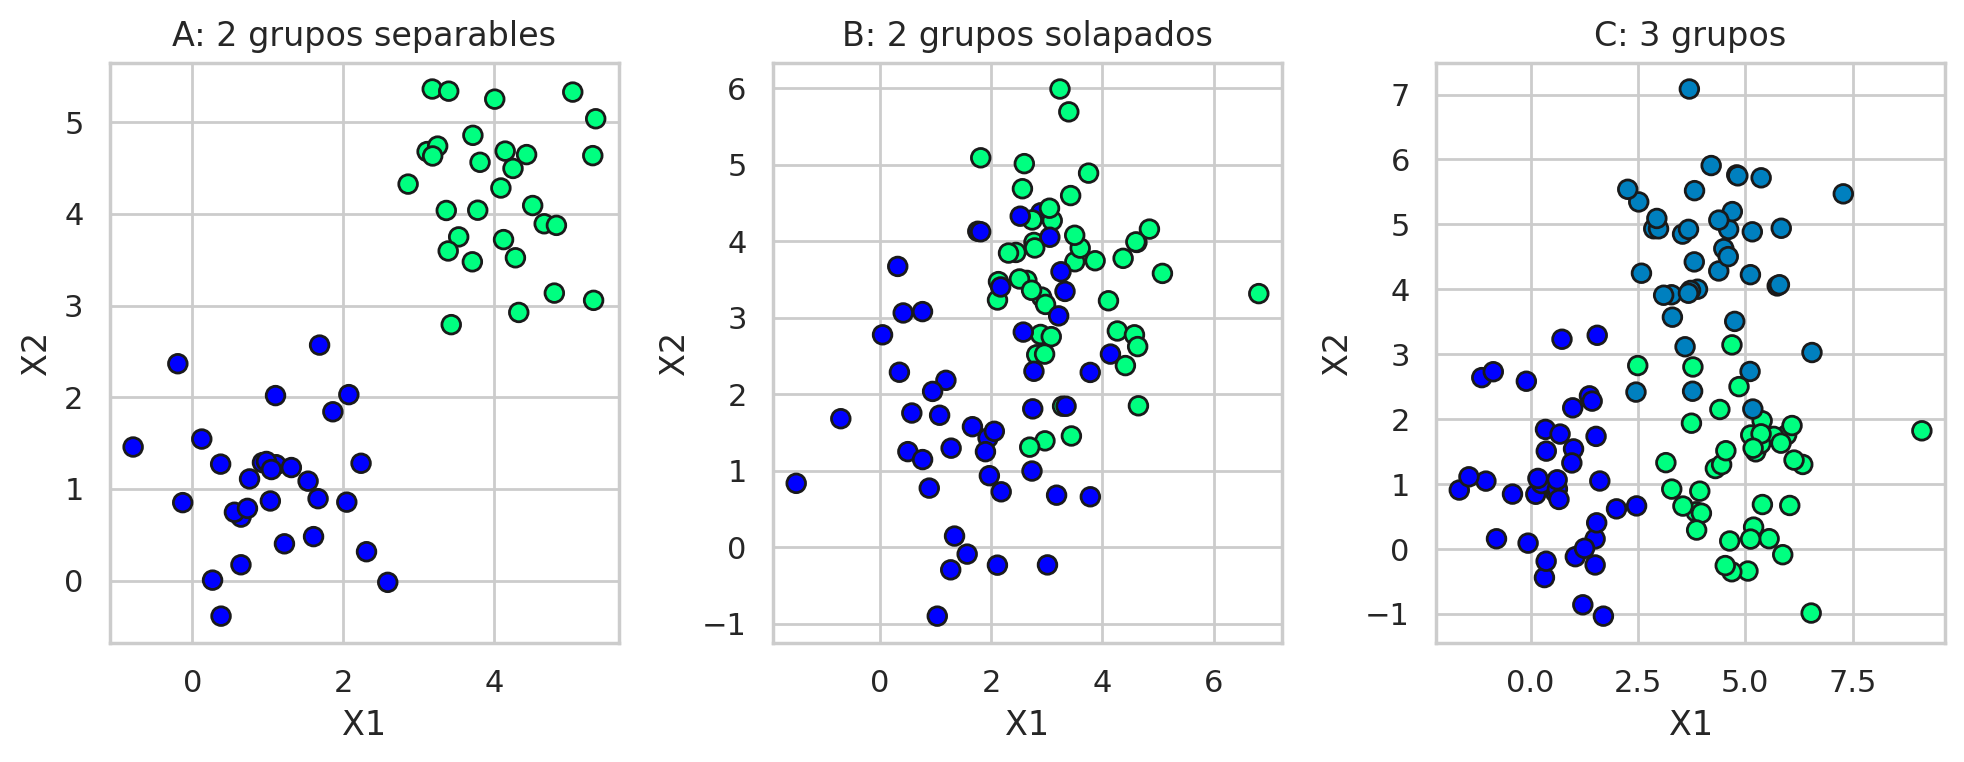

In [64]:
# Juguete A: dos grupos separables linealmente
XA, yA = make_blobs(n_samples=60, centers=[[1, 1], [4, 4]], cluster_std=0.7, random_state=0)
# Juguete B: dos grupos solapados (frontera no clara)
XB, yB = make_blobs(n_samples=90, centers=[[2, 2], [3.6, 3.4]], cluster_std=1.2, random_state=3)
# Juguete C: tres grupos
XC, yC = make_blobs(n_samples=120, centers=[[1, 1], [4, 4.5], [5, 1]], cluster_std=1.0, random_state=2)
# Representamos los conkuntos de datos simulados
fig, ax = plt.subplots(1, 3, figsize=(10, 4))
for a, (X, y, t) in zip(ax, [(XA, yA, 'A: 2 grupos separables'), (XB, yB, 'B: 2 grupos solapados'), (XC, yC, 'C: 3 grupos')]):
    a.scatter(X[:, 0], X[:, 1], c=y, s=45, cmap='winter', edgecolor='k')
    a.set_title(t)
    a.set_xlabel('X1')
    a.set_ylabel('X2')
plt.tight_layout()
plt.show()

## <font color="steelblue">1.1. Hiperplanos</font>

En un espacio de $p$ dimensiones, un **hiperplano** es un subespacio **plano** de dimensión $p-1$. En 2D es una **recta**; en 3D, un **plano**; en más dimensiones no podemos visualizarlo, pero la idea se mantiene. Un hiperplano se describe con la ecuación

$$\beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p = 0.$$

Lo importante para clasificar es el **signo**: si para un punto $\mathbf{x}$ el resultado es $>0$ cae a un lado, y si es $<0$ al otro. Un hiperplano **parte el espacio en dos mitades**, una para cada clase. Más aún, la **distancia perpendicular** de un punto $\mathbf{x}$ al hiperplano es

$$\text{dist}(\mathbf{x}) = \frac{\beta_0 + \boldsymbol\beta^\top\mathbf{x}}{\lVert\boldsymbol\beta\rVert},$$

cuyo **valor absoluto** mide cuán lejos está el punto de la frontera y cuyo **signo** indica el lado. Esta fórmula será la clave para definir el margen.

El problema es que, si dos grupos son separables, **existen infinitas rectas** que los separan. Vemos varias sobre el juguete A:

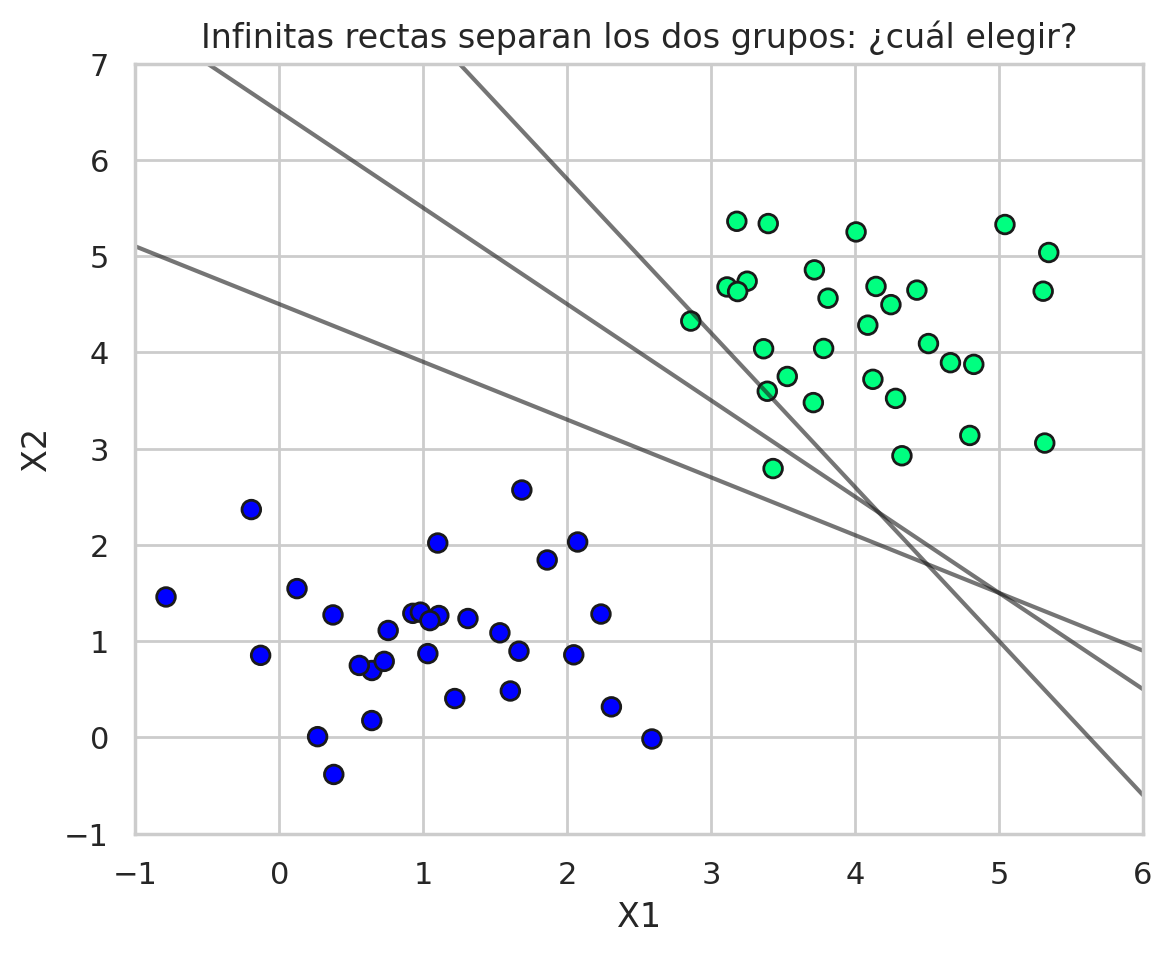

In [65]:
xfit = np.linspace(-1, 6, 100)
plt.figure(figsize=(6.5, 5))
plt.scatter(XA[:, 0], XA[:, 1], c=yA, s=45, cmap='winter', edgecolor='k')
for m, b in [(-1.0, 6.5), (-0.6, 4.5), (-1.6, 9.0)]:
    plt.plot(xfit, m * xfit + b, '-k', alpha=.6)
plt.xlim(-1, 6)
plt.ylim(-1, 7)
plt.title('Infinitas rectas separan los dos grupos: ¿cuál elegir?')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

Las tres rectas separan bien los datos de entrenamiento, pero ¿cuál generalizará mejor a datos nuevos? La SVM responde con un criterio claro: **la que deja el mayor margen**.

## <font color="steelblue">1.2. Clasificador de margen máximo (caso separable)</font>

De entre todas las rectas separadoras, la SVM elige el **hiperplano de margen máximo**: aquel cuya **distancia mínima** a las observaciones (el **margen**) es **lo más grande posible**. Geométricamente, es la frontera que deja el "pasillo" más ancho entre las dos clases.

Las observaciones que quedan **justo sobre el borde** del margen se llaman **vectores soporte**: son las únicas que **definen** el hiperplano. Si movemos un vector soporte, la frontera cambia; si movemos cualquier otra observación (lejos del margen), la frontera **no se entera**. Esta propiedad hace al modelo **robusto** y **eficiente**.

Matemáticamente, codifiquemos las clases como $y_i \in \{-1, +1\}$ y llamemos $f(\mathbf{x}) = \beta_0 + \boldsymbol\beta^\top\mathbf{x}$. Como los parámetros $(\beta_0, \boldsymbol\beta)$ se pueden **reescalar** libremente sin cambiar el hiperplano, adoptamos la **normalización canónica**: exigimos que en los puntos más cercanos se cumpla $|f(\mathbf{x})| = 1$. Con esa convención, la distancia del hiperplano al punto más próximo es $1/\lVert\boldsymbol\beta\rVert$ y, por tanto, la **anchura total del margen** es

$$M = \frac{2}{\lVert\boldsymbol\beta\rVert}.$$

Maximizar el margen $M$ equivale entonces a **minimizar** $\lVert\boldsymbol\beta\rVert$ (o, más cómodo, $\tfrac12\lVert\boldsymbol\beta\rVert^2$) imponiendo que **cada punto quede en su lado y fuera del margen**, es decir
$$y_i\,f(\mathbf{x}_i) \ge 1.$$

El **problema primal de margen duro** es:

$$\min_{\beta_0,\,\boldsymbol\beta}\ \tfrac12\lVert\boldsymbol\beta\rVert^2 \quad \text{sujeto a}\quad y_i\,(\beta_0 + \boldsymbol\beta^\top\mathbf{x}_i) \ge 1,\quad i = 1,\dots,n.$$

Es un problema de **optimización convexa con restricciones** (programación cuadrática), que tiene **solución única**. Las observaciones para las que la restricción se cumple con **igualdad** ($y_i f(\mathbf{x}_i) = 1$) son los denominados **vectores soporte**: están justo sobre el borde del margen y son las únicas que lo determinan. Lo visualizamos sobre el banco de datos A (línea continua = hiperplano; discontinuas = bordes del margen; puntos rodeados = vectores soporte):

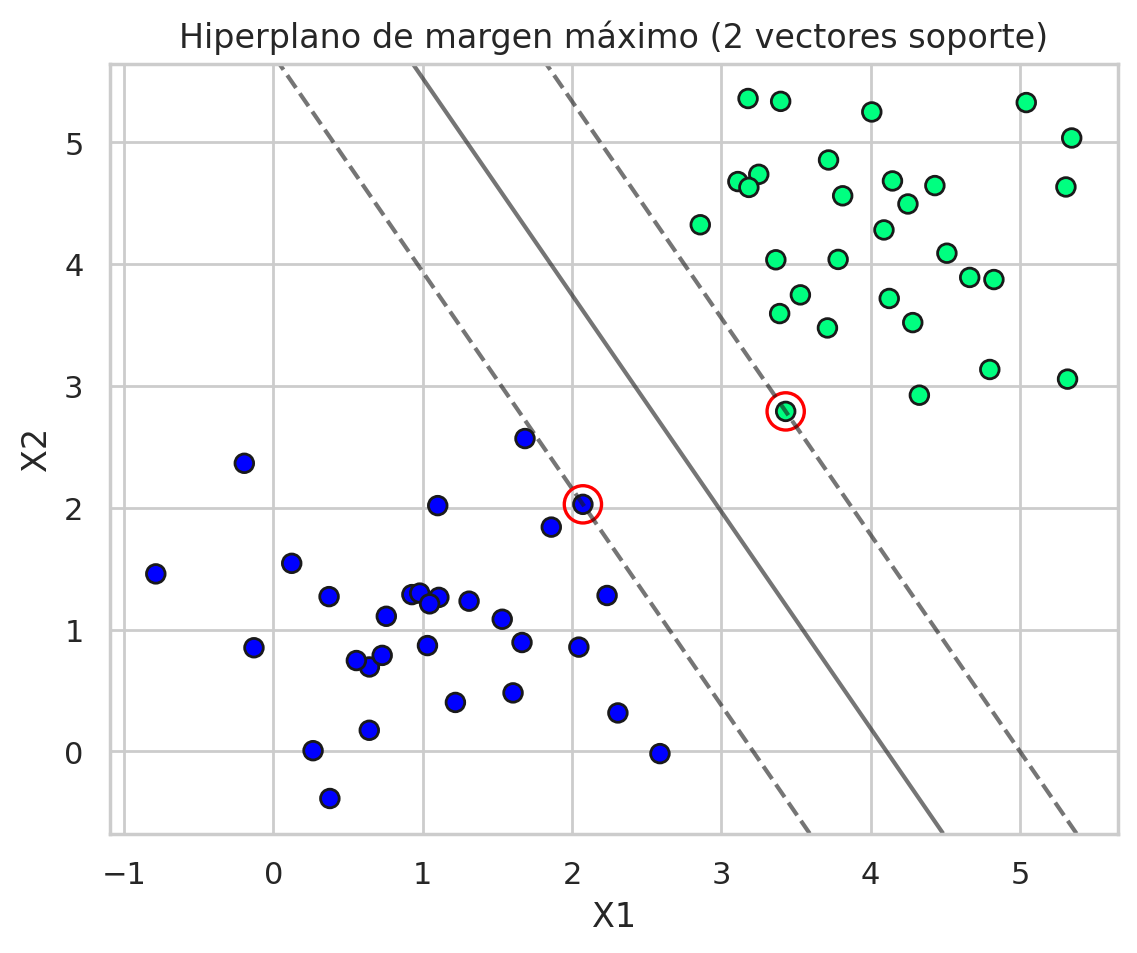

In [66]:
# Función para definir los hiperpalnos y los vectores soporte
def plot_svc(model, ax, plot_support=True):
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 30); yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx); xy = np.vstack([XX.ravel(), YY.ravel()]).T
    P = model.decision_function(xy).reshape(XX.shape)
    ax.contour(XX, YY, P, colors='k', levels=[-1, 0, 1], alpha=.6, linestyles=['--', '-', '--'])
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=180, linewidth=1.2, facecolors='none', edgecolors='red')
    ax.set_xlim(xlim); ax.set_ylim(ylim)

# Entrenamiento del modelo
modelo = SVC(kernel='linear', C=1e10).fit(XA, yA)
# Representación gráfica de la solución
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(XA[:, 0], XA[:, 1], c=yA, s=45, cmap='winter', edgecolor='k')
plot_svc(modelo, ax)
ax.set_title(f'Hiperplano de margen máximo ({modelo.support_vectors_.shape[0]} vectores soporte)')
ax.set_xlabel('X1')
ax.set_ylabel('X2')
plt.show()

La frontera continua se sitúa **equidistante** de los dos grupos y su margen (banda entre las discontinuas) es el más ancho posible. Solo unos pocos puntos (los rodeados en rojo) tocan el borde: son los **vectores soporte**. El resto de observaciones podrían moverse libremente sin alterar la solución.



## <font color="steelblue">1.3. Margen blando (*Support Vector Classifier*)</font>

El margen máximo solo existe si las clases son **perfectamente separables**, algo rarísimo en la práctica (mira el juguete B). Además, exigir separación perfecta hace el modelo **frágil** (una sola observación nueva puede cambiarlo todo) y propenso al **sobreajuste**.

La solución es el **margen blando** (*soft margin*): permitir que **algunas** observaciones violen el margen —o incluso queden en el lado equivocado— a cambio de una frontera más **ancha y robusta**. A cada observación se le asigna una **holgura** $\xi_i \ge 0$ que mide cuánto incumple su restricción, y el **problema primal de margen blando** queda:

$$\min_{\beta_0,\,\boldsymbol\beta,\,\boldsymbol\xi}\ \tfrac12\lVert\boldsymbol\beta\rVert^2 + C\sum_{i=1}^n \xi_i \quad\text{sujeto a}\quad y_i\,(\beta_0+\boldsymbol\beta^\top\mathbf{x}_i) \ge 1 - \xi_i,\quad \xi_i \ge 0.$$

El valor de cada holgura tiene una lectura geométrica directa: $\xi_i = 0$ → el punto está **bien clasificado y fuera** del margen; $0 < \xi_i \le 1$ → está **dentro** del margen pero en el lado correcto; $\xi_i > 1$ → está **mal clasificado**. El término $\sum_i \xi_i$ acota el "total de violaciones" permitido.

El hiperparámetro **$C$** controla **cuánto se penalizan** las violaciones, y gobierna el **compromiso sesgo–varianza**:

* **$C$ grande**: se toleran pocas violaciones → margen **estrecho**, **pocos** vectores soporte → bajo sesgo, **alta varianza** (riesgo de sobreajuste). En el límite $C\to\infty$ se recupera el margen máximo.
* **$C$ pequeño**: se toleran muchas violaciones → margen **ancho**, **muchos** vectores soporte → **alto sesgo**, baja varianza.

Lo vemos en el juguete B variando $C$: observa cómo se **ensancha el margen** y **crece el número de vectores soporte** al disminuir $C$.

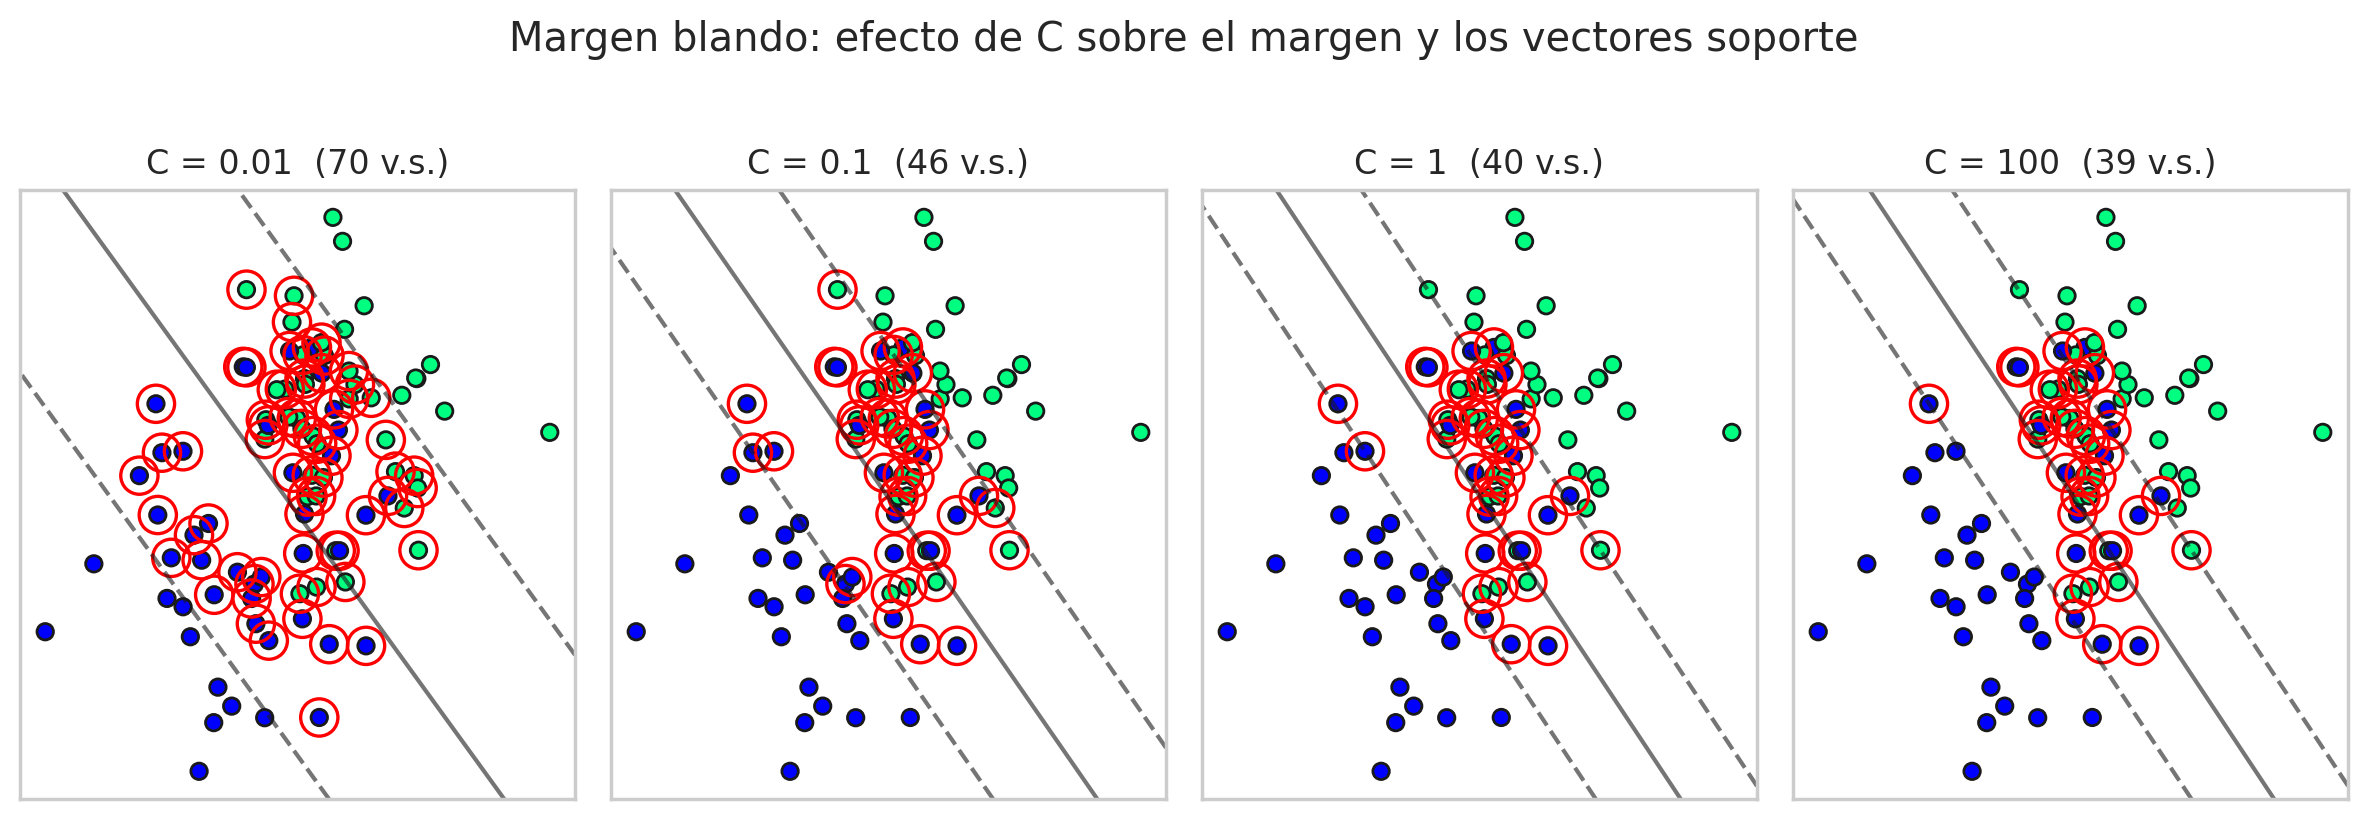

     C  nº vectores soporte  exactitud_train
  0.01                   70            0.811
  0.10                   46            0.822
  1.00                   40            0.822
100.00                   39            0.811


In [67]:
Cs = [0.01, 0.1, 1, 100]
fig, ax = plt.subplots(1, 4, figsize=(12, 4))
filas = []
for a, C in zip(ax, Cs):
    m = SVC(kernel='linear', C=C).fit(XB, yB)
    a.scatter(XB[:, 0], XB[:, 1], c=yB, s=35, cmap='winter', edgecolor='k')
    plot_svc(m, a)
    a.set_title(f'C = {C}  ({m.support_vectors_.shape[0]} v.s.)'); a.set_xticks([]); a.set_yticks([])
    filas.append({'C': C, 'nº vectores soporte': m.support_vectors_.shape[0],
                  'exactitud_train': round(m.score(XB, yB), 3)})
plt.suptitle('Margen blando: efecto de C sobre el margen y los vectores soporte', y=1.02)
plt.tight_layout()
plt.show()
print(pd.DataFrame(filas).to_string(index=False))

Con **$C$ pequeño** el margen es ancho y casi todas las observaciones de la zona de solape son vectores soporte: la frontera está "sustentada" por muchos puntos, es estable (poca varianza) pero algo sesgada. Con **$C$ grande** el margen se estrecha, hay menos vectores soporte y la frontera se ajusta más a los datos (más varianza). El $C$ óptimo se debe elegir por **validación cruzada**.

## <font color="steelblue">1.4. Formulación dual y vectores soporte</font>

El problema primal se resuelve habitualmente a través de su **formulación dual** (mediante multiplicadores de Lagrange $\alpha_i \ge 0$), que tiene una forma especialmente reveladora:

$$\max_{\boldsymbol\alpha}\ \sum_{i=1}^n \alpha_i - \tfrac12 \sum_{i=1}^n\sum_{j=1}^n \alpha_i \alpha_j\, y_i y_j\, \mathbf{x}_i^\top \mathbf{x}_j \quad\text{sujeto a}\quad 0 \le \alpha_i \le C,\quad \sum_{i=1}^n \alpha_i y_i = 0.$$

De su solución se recupera el vector de pesos como combinación de las observaciones:

$$\boldsymbol\beta = \sum_{i=1}^n \alpha_i\, y_i\, \mathbf{x}_i.$$

Lo notable es que **la mayoría de los $\alpha_i$ valen cero**. Las (pocas) observaciones con $\alpha_i > 0$ son exactamente los **vectores soporte**. Las condiciones de optimalidad (KKT) las clasifican de forma elegante:

* $\alpha_i = 0$: el punto está **fuera del margen**, bien clasificado → **no influye** en el hiperplano.
* $0 < \alpha_i < C$: el punto está **justo sobre el borde** del margen.
* $\alpha_i = C$: el punto está **dentro del margen o mal clasificado** (su holgura $\xi_i > 0$).

Como $\boldsymbol\beta$ es combinación solo de los vectores soporte, la **función de decisión** se escribe únicamente con ellos y con **productos escalares**:

$$f(\mathbf{x}) = \sum_{i\,\in\,\text{SV}} \alpha_i\, y_i\, \mathbf{x}_i^\top \mathbf{x} + \beta_0, \qquad \text{y se predice } \operatorname{signo}\bigl(f(\mathbf{x})\bigr).$$

Esta dependencia **solo del producto escalar** $\mathbf{x}_i^\top \mathbf{x}$ tiene una consecuencia enorme: si lo sustituimos por una función $K(\mathbf{x}_i, \mathbf{x})$ —un *kernel*— obtenemos fronteras **no lineales** sin cambiar nada más del algoritmo. Esa es la idea de la SVM con kernels que veremos en el cuaderno siguiente; aquí nos quedamos con $K(\mathbf{x}_i,\mathbf{x}) = \mathbf{x}_i^\top\mathbf{x}$ (el caso lineal).



## <font color="steelblue">1.5. La función de pérdida *hinge*</font>

El problema del margen blando se puede reescribir, sin restricciones, como la minimización de una **pérdida** más una **regularización**:

$$\min_{\boldsymbol\beta}\ \underbrace{\tfrac12\lVert\boldsymbol\beta\rVert^2}_{\text{regularización}} + C\sum_{i=1}^n \underbrace{\max\bigl(0,\ 1 - y_i\, f(\mathbf{x}_i)\bigr)}_{\text{pérdida }hinge},$$

donde $f(\mathbf{x}) = \beta_0 + \boldsymbol\beta^\top\mathbf{x}$ y las clases se codifican como $y_i \in \{-1, +1\}$. La **pérdida *hinge*** ("bisagra") vale **cero** cuando el punto está bien clasificado **y** fuera del margen ($y_i f(\mathbf{x}_i) \ge 1$), y crece **linealmente** a medida que el punto se adentra en el margen o se clasifica mal. Es decir: solo penaliza a los puntos "problemáticos" (los futuros vectores soporte). La visualizamos:

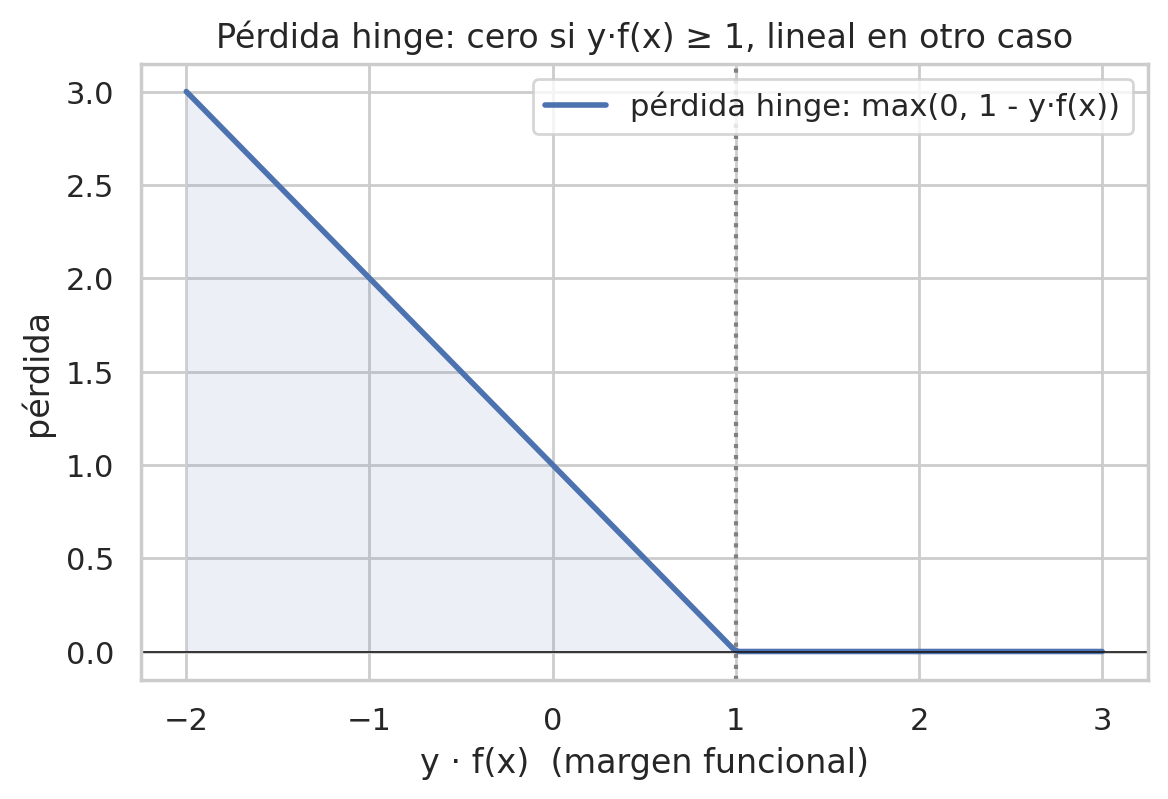

In [68]:
z = np.linspace(-2, 3, 200)
plt.figure(figsize=(6.5, 4))
plt.plot(z, np.maximum(0, 1 - z), lw=2, label='pérdida hinge: max(0, 1 - y·f(x))')
plt.axvline(1, ls=':', color='gray')
plt.axhline(0, color='k', lw=.6)
plt.fill_between(z, 0, np.maximum(0, 1 - z), alpha=.1)
plt.xlabel('y · f(x)  (margen funcional)')
plt.ylabel('pérdida')
plt.title('Pérdida hinge: cero si y·f(x) ≥ 1, lineal en otro caso')
plt.legend()
plt.show()

A la derecha de 1 (puntos bien clasificados y lejos de la frontera) la pérdida es **cero**: esos puntos no influyen. A la izquierda, la penalización crece de forma lineal. El término $C$ multiplica esta pérdida, así que **$C$ grande** = penalizar mucho los errores (menos regularización), y **$C$ pequeño** = tolerarlos (más regularización). Esto conecta con la idea de sesgo–varianza de la sección anterior.



## <font color="steelblue">1.6. Clasificación multiclase</font>

El hiperplano separa **dos** clases, así que para $K>2$ clases se combinan varios clasificadores binarios. Las estrategias habituales son:

* **Uno contra uno** (*one-vs-one*, OvO): se entrena un SVM para **cada par** de clases ($K(K-1)/2$ en total) y se asigna la clase **más votada**. Es la que usa `SVC` de scikit-learn.
* **Uno contra el resto** (*one-vs-rest*, OvR): se entrena **un SVM por clase** (esa clase frente a todas las demás) y se asigna la de mayor puntuación. Es la que usa `LinearSVC`. Es más rápida pero entrena de forma desbalanceada.
* **DAGSVM**: una mejora de OvO que reduce el número de comparaciones mediante un grafo dirigido acíclico.

Lo vemos en el juguete C (tres grupos), dibujando las regiones de decisión:

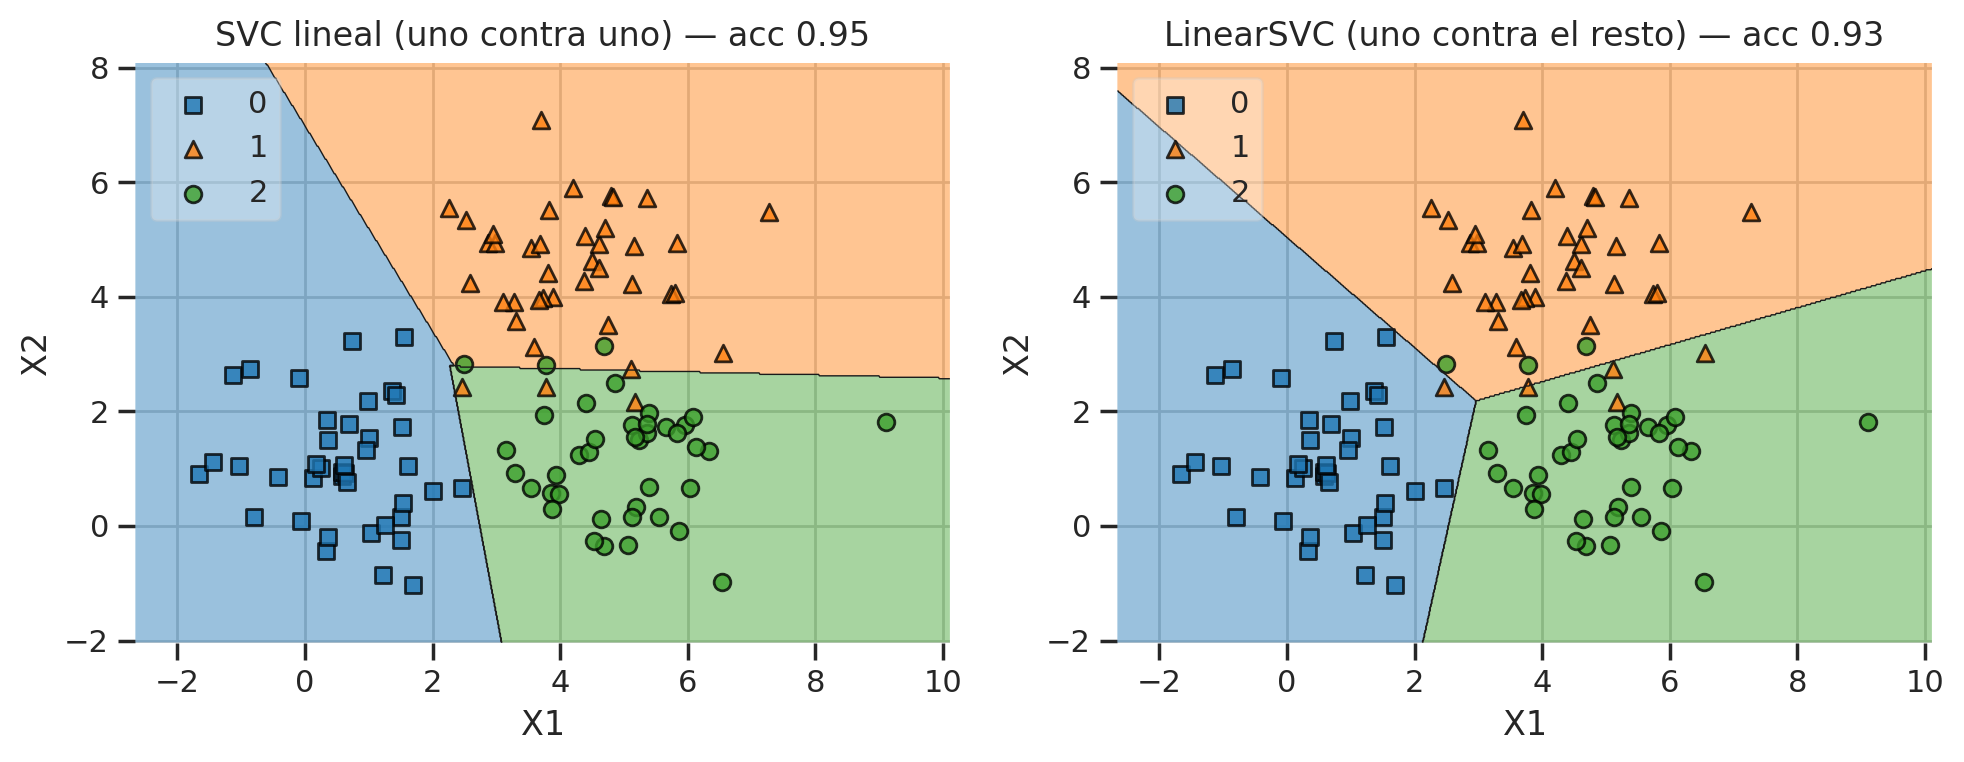

In [69]:
# Regiones de decisión para el ejemplo C
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for a, (m, t) in zip(ax, [(SVC(kernel='linear', C=1).fit(XC, yC), 'SVC lineal (uno contra uno)'),
                          (LinearSVC(C=1, dual=False, max_iter=5000).fit(XC, yC), 'LinearSVC (uno contra el resto)')]):
    plot_decision_regions(X=XC, y=yC, clf=m, ax=a, legend=2)
    a.set_title(f'{t} — acc {m.score(XC, yC):.2f}')
    a.set_xlabel('X1')
    a.set_ylabel('X2')
plt.tight_layout()
plt.show()

Ambas estrategias trazan **fronteras rectas** que dividen el plano en tres regiones. Como las fronteras son lineales, allí donde los grupos se solapan aparecen errores inevitables (un clasificador lineal no puede "rodear" un grupo). Las dos soluciones son parecidas pero no idénticas, porque combinan los binarios de forma distinta.

## <font color="steelblue">1.7. Ventajas, desventajas y el límite de lo lineal</font>

La SVM es **eficaz en muchas dimensiones**, **robusta** (depende solo de los vectores soporte) y tiene una formulación con **buenas garantías** teóricas; con margen blando controla bien el sobreajuste vía $C$.

Entre las desventajas podemos destacar que la versión lineal **no captura fronteras curvas**, la elección de $C$ es delicada, escala mal con muestras muy grandes, y `LinearSVC` **no da probabilidades** directamente (usa `decision_function`).

El gran límite es la **linealidad**: cuando las clases se separan por una frontera **curva**, ninguna recta funcionará bien. La solución son los **kernels**, que proyectan los datos a un espacio de mayor dimensión donde **sí** son separables linealmente; eso es la SVM "completa", que veremos en el cuaderno siguiente.

# <font color="steelblue">2. SVM lineal en scikit-learn</font>

Para clasificación lineal hay dos opciones, y conviene saber cuándo usar cada una:

* **`LinearSVC`** — implementada sobre *liblinear*. Es **mucho más rápida** y escala bien con **muchas muestras y muchas variables** (incluidas matrices dispersas, como el texto); su coste crece de forma aproximadamente lineal. Resuelve el multiclase con **uno-contra-el-resto (OvR)**. A cambio, **no admite *kernels***, **no expone `support_vectors_`** y **no tiene `predict_proba`**.
* **`SVC(kernel='linear')`** — implementada sobre *libsvm*. Es **más lenta** (su coste crece entre cuadrática y cúbicamente con el nº de muestras, así que se atasca con decenas de miles de datos), pero ofrece los **`support_vectors_`**, `predict_proba` (si `probability=True`) y la puerta a los ***kernels*** del cuaderno siguiente. Resuelve el multiclase con **uno-contra-uno (OvO)**.

En resumen: `LinearSVC` para **rendimiento y escala**; `SVC(kernel='linear')` cuando necesites **vectores soporte, probabilidades o kernels**. En este cuaderno usaremos `LinearSVC` en las aplicaciones. Sus parámetros principales:

| Parámetro | Descripción | Por defecto |
|---|---|---|
| **`C`** | Regularización (inversa): grande = penaliza más los errores, margen estrecho; pequeño = margen ancho, más regularización. | `1.0` |
| **`penalty`** | Norma de la penalización: `'l2'` (estándar) o `'l1'` (coeficientes **dispersos**, hace selección de variables). | `'l2'` |
| **`loss`** | Pérdida: `'hinge'` (SVM estándar) o `'squared_hinge'` (su cuadrado, penaliza más los errores grandes). | `'squared_hinge'` |
| **`dual`** | Resuelve el problema **dual** o **primal**. `'auto'` lo elige por ti; conviene el **primal** (`False`) cuando nº muestras > nº variables. | `'auto'` |
| **`multi_class`** | Estrategia multiclase: `'ovr'` (uno contra el resto) o `'crammer_singer'` (formulación conjunta, más lenta y rara vez mejor). | `'ovr'` |
| **`class_weight`** | Pesos por clase; `'balanced'` compensa el desbalanceo automáticamente (inverso a la frecuencia). | `None` |
| **`max_iter`** | Iteraciones máximas del optimizador (subir si avisa de no convergencia). | `1000` |
| **`random_state`** | Semilla para reproducibilidad. | `None` |

Hay tres parámetros más, secundarios pero útiles: **`tol`** (`1e-4`, tolerancia de parada), **`fit_intercept`** (`True`, si se estima $\beta_0$) e **`intercept_scaling`** (mitiga la regularización del sesgo).

**Combinaciones válidas de `penalty`, `loss` y `dual`**

No todas las combinaciones son compatibles (es la fuente de error más habitual con `LinearSVC`):

* `penalty='l2'` + `loss='squared_hinge'` → admite `dual=True` **o** `False` (la configuración por defecto y más flexible).
* `penalty='l2'` + `loss='hinge'` → **solo** `dual=True`.
* `penalty='l1'` + `loss='squared_hinge'` → **solo** `dual=False`.
* `penalty='l1'` + `loss='hinge'` → **no soportada**.

Con `dual='auto'`, scikit-learn elige una opción válida automáticamente, lo que evita la mayoría de estos choques.

**Métodos y atributos**

Entre los **métodos** destacan: `fit`, `predict`, **`decision_function`** (la puntuación $f(\mathbf{x})=\beta_0+\boldsymbol\beta^\top\mathbf{x}$, distancia con signo al hiperplano, útil para la **curva ROC** y para ordenar por confianza), `score`, y `densify`/`sparsify` (formato denso/disperso de `coef_`).

Entre los **atributos tras ajustar**: **`coef_`** (los $\boldsymbol\beta$, un peso por variable; forma `(1, n_features)` en binario y `(n_clases, n_features)` en multiclase) e **`intercept_`** ($\beta_0$), además de `classes_`, `n_iter_`, `n_features_in_` y `feature_names_in_`. Como el modelo es lineal, `coef_` es directamente **interpretable**: el signo y la magnitud de cada peso indican cómo empuja esa variable hacia una u otra clase (siempre que las predictoras estén **estandarizadas**, para que sean comparables).

> **Ojo:** `LinearSVC` **no** tiene `predict_proba`. Si necesitas probabilidades, tienes tres vías: usar `decision_function` (suficiente para ROC/umbral), envolver el modelo en `CalibratedClassifierCV`, o cambiar a `SVC(kernel='linear', probability=True)`

In [70]:
# Veamos los resulatdos sobre nuestro ejemplo A
m = LinearSVC(C=1, dual=False, max_iter=5000).fit(XA, yA)
print('coef_ (β1, β2):', np.round(m.coef_, 3), '| intercept_ (β0):', np.round(m.intercept_, 3))
print('classes_:', m.classes_)
print('predict (5 primeros):', m.predict(XA[:5]))
print('decision_function (5 primeros):', np.round(m.decision_function(XA[:5]), 2))

coef_ (β1, β2): [[0.431 0.379]] | intercept_ (β0): [-2.066]
classes_: [0 1]
predict (5 primeros): [1 0 0 1 0]
decision_function (5 primeros): [ 0.88 -0.4  -1.32  1.19 -0.99]


`coef_` e `intercept_` son los parámetros del hiperplano $\beta_0 + \beta_1 x_1 + \beta_2 x_2 = 0$. `decision_function` devuelve la **distancia con signo** de cada punto al hiperplano: su **signo** da la clase y su **magnitud**, la "confianza" (cuanto más lejos del margen, más seguro). Esa puntuación es la que usaremos en la curva ROC.


# <font color="steelblue">3. Aplicaciones</font>

Aplicamos la SVM lineal a dos problemas de clasificación. Optimizamos $C$ por validación cruzada y la mostramos gráficamente.

En primer luagr definimos una función para el proceso de validación cruzada del parámetro `C`, y representamos la solución gráficamente.

In [71]:
def cv_C(gs, titulo):
    r = pd.DataFrame(gs.cv_results_).sort_values('param_C')
    plt.figure(figsize=(7, 4))
    plt.plot(r.param_C, r.mean_test_score, marker='o')
    plt.xscale('log'); plt.xlabel('C (escala log)'); plt.ylabel('exactitud (validación cruzada)')
    plt.title(f"{titulo} — óptimo C={gs.best_params_['C']} (acc CV={gs.best_score_:.3f})")
    plt.grid(True, alpha=.3)
    plt.show()

## <font color="steelblue">3.1. Breast Cancer Wisconsin (2 clases)</font>

Comenzamos con ejemplo de breast cancer donde deseamos clasificar tumores como **benignos (B)** o **malignos (M)** a partir de 30 características celulares.

In [72]:
# Cargamos los datos
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/cancer_clean.csv'
cancer = pd.read_csv(url, index_col=0)
cancer['diagnosis'] = cancer['diagnosis'].astype('category')

Como sabemos por cuadernos anteriores hay un desbalanceo moderado (más benignos). Preparamos los datos para el entrenamiento del modelo:

In [73]:
strain_raw, stest_raw = split_sample(cancer, 'diagnosis', 0.3, 0, True)
strain, prep = preprocesar_datos(strain_raw, 'diagnosis')
stest,  _    = preprocesar_datos(stest_raw,  'diagnosis', prep)
xtrain, ytrain = strain.drop('diagnosis', axis=1), strain['diagnosis']
xtest,  ytest  = stest.drop('diagnosis', axis=1),  stest['diagnosis']
print('Entrenamiento:', xtrain.shape, '| Test:', xtest.shape)

Estratificando por 'diagnosis'.
  Entrenamiento: 398 muestras | Test: 171 muestras
Entrenamiento: (398, 30) | Test: (171, 30)


### <font color="steelblue">Selección de C (solución gráfica)</font>

Utilizamos la función definida apra realziar el análisis de validación cruzada del parámetro `C`.

Mejor C: {'C': 0.1} | acc CV: 0.975


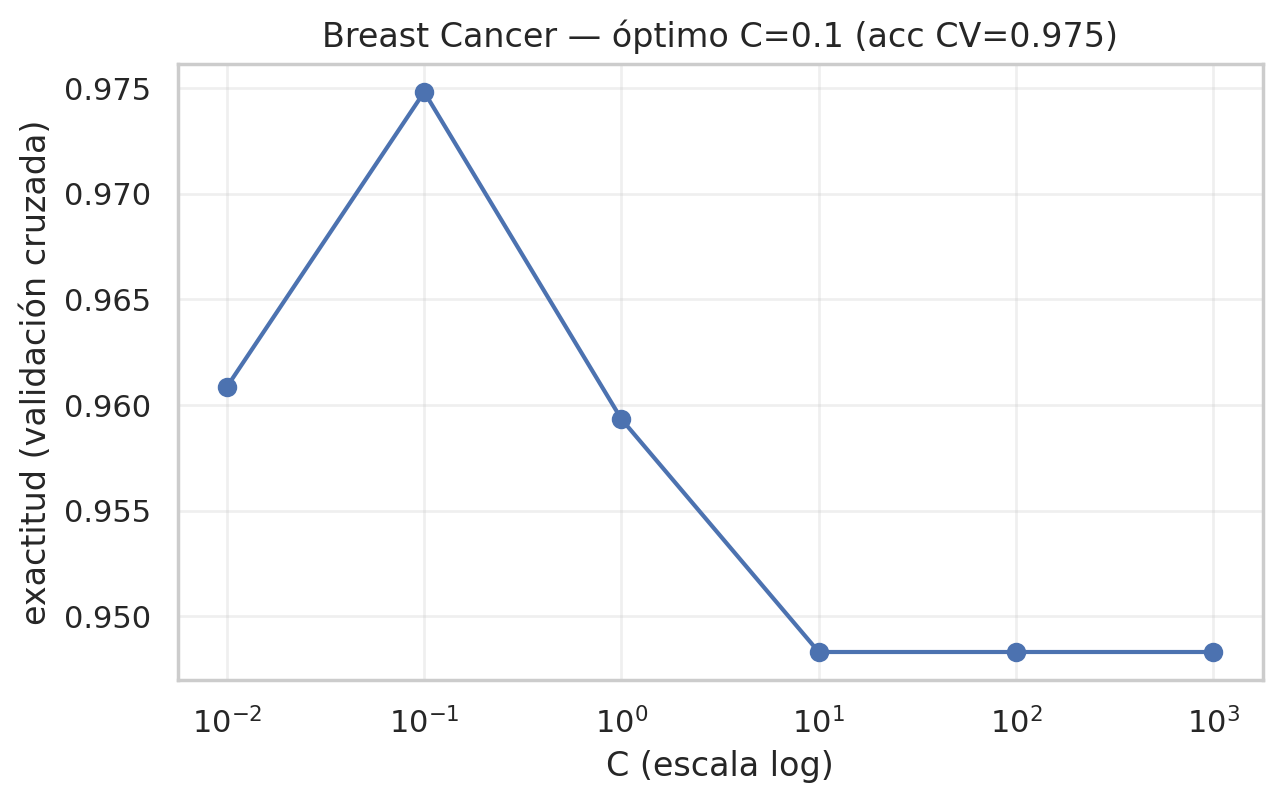

In [74]:
from sklearn.metrics import make_scorer, recall_score

recall_maligno = make_scorer(recall_score, pos_label='M')
pgrid = {'C': [0.01, 0.1, 1, 10, 100, 1000]}
gs = GridSearchCV(LinearSVC(dual=False, max_iter=5000), pgrid, scoring=recall_maligno, cv=KFold(10))
gs.fit(xtrain, ytrain)
print('Mejor C:', gs.best_params_, '| acc CV:', round(gs.best_score_, 3))
cv_C(gs, 'Breast Cancer')

La curva muestra cómo varía la exactitud con $C$; en este caso el óptimo se alcanza en el valor 0.1 (indicando una mayor regularización), porque con 30 variables conviene una frontera robusta. Evaluamos el modelo con las funciones que hemos venido utilizando. Comenzamos con el informe de clasificación:

In [75]:
modelo = gs.best_estimator_
reports_clas(modelo, xtrain, ytrain, xtest, ytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           B       0.99      1.00      1.00       250
           M       1.00      0.99      0.99       148

    accuracy                           0.99       398
   macro avg       1.00      0.99      0.99       398
weighted avg       1.00      0.99      0.99       398


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           B       0.95      0.98      0.97       107
           M       0.97      0.92      0.94        64

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



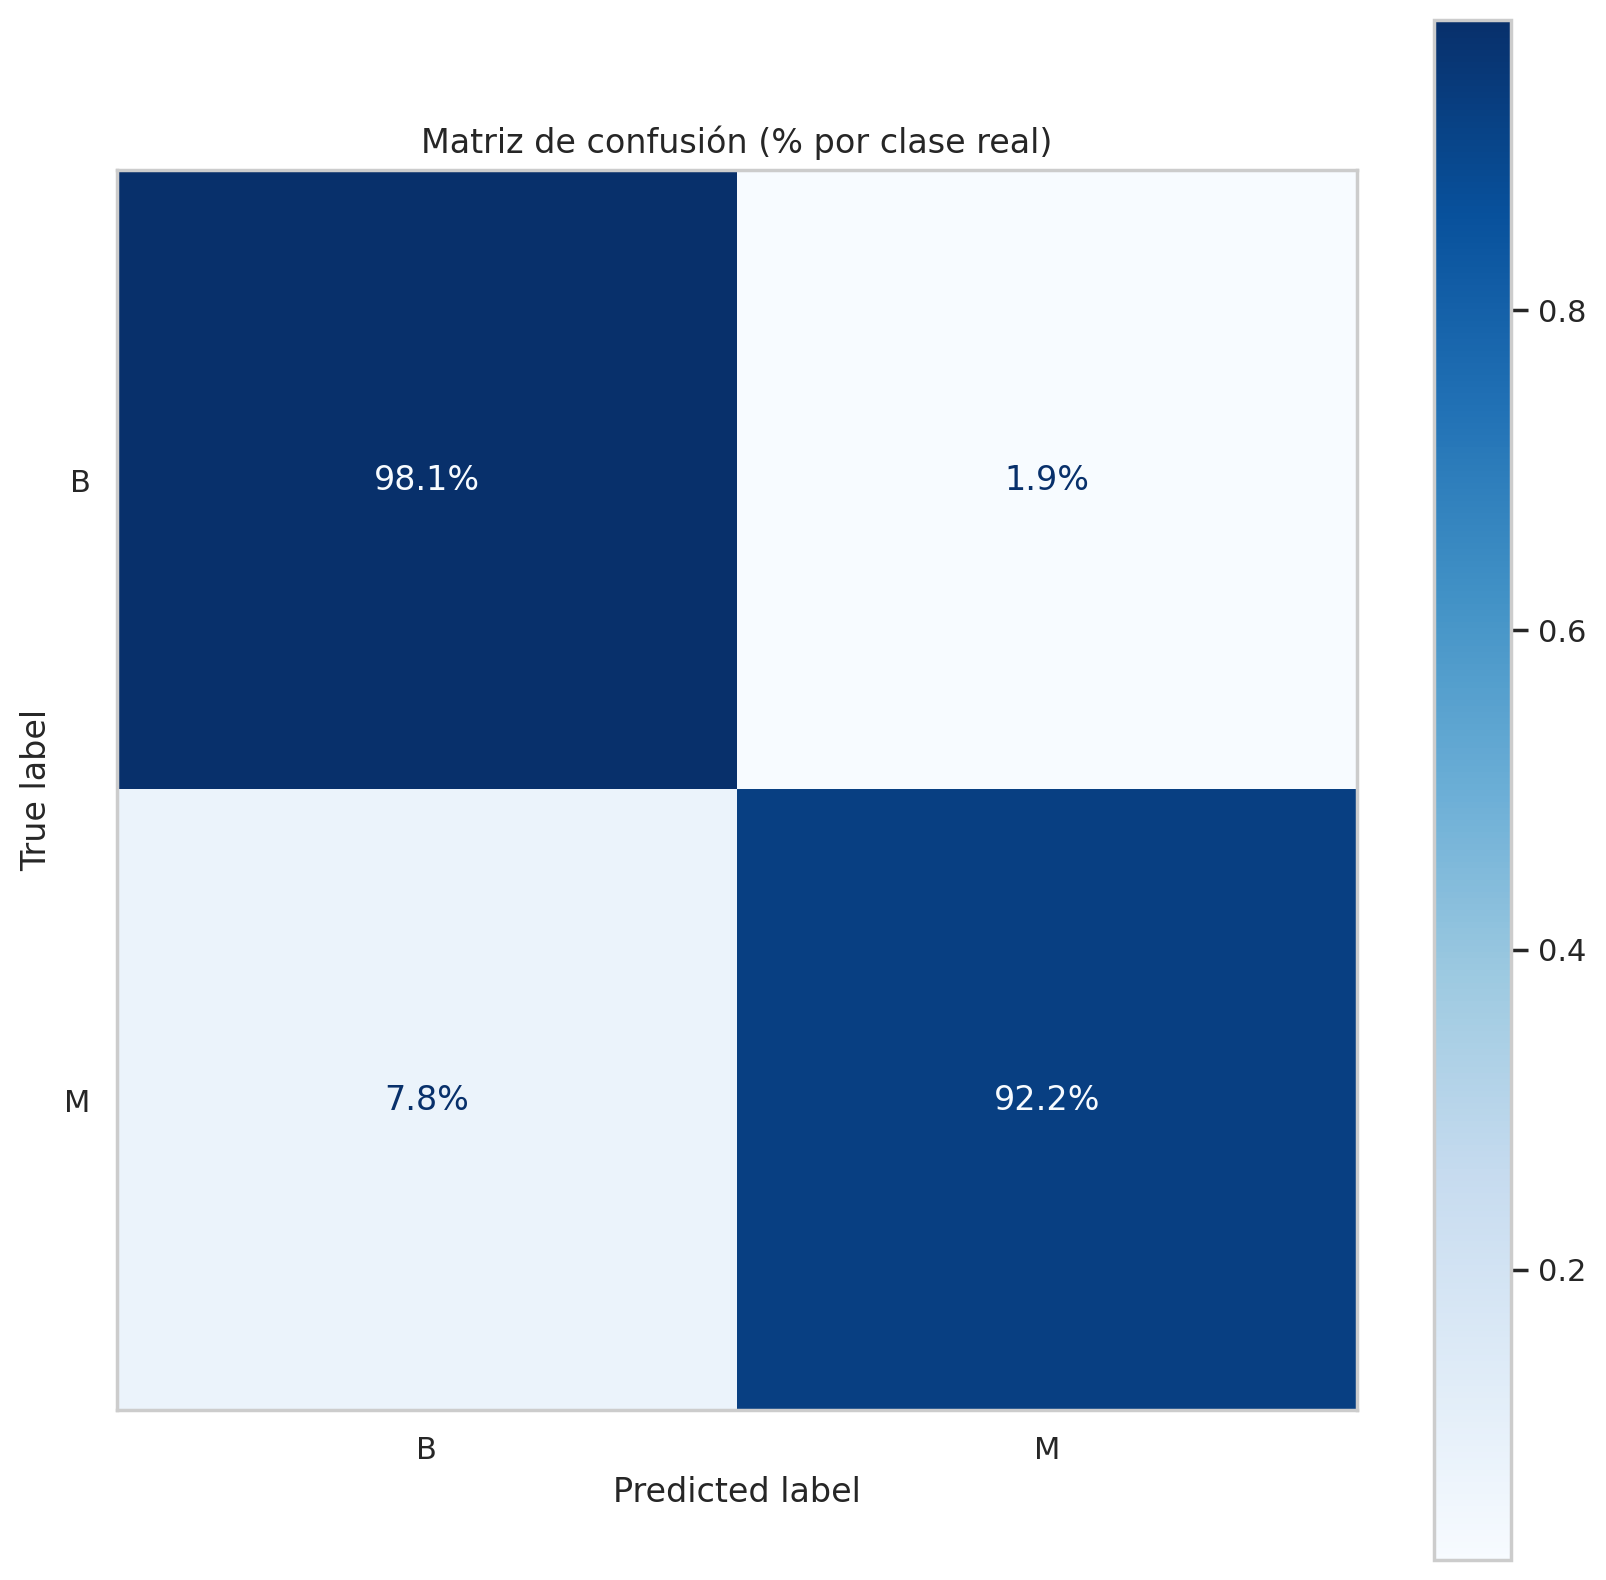

In [76]:
matriz_confusion(modelo, xtest, ytest);

Como era de esperar los resultados son bastante buenos, aunque se observa un 7.8% de error a la hora de clasificar los tumores malignos.

Veamos el análisis de validación para tener una mayor conocimiento sobre el comportamiento del modelo.

In [77]:
val = validar_modelo(modelo, xtrain, ytrain, 'recall', 10)

Validacion cruzada (10 folds, score=recall): media = 0.973 +/- 0.044


El recall es del 97.3% mostrando un buen comportamiento.

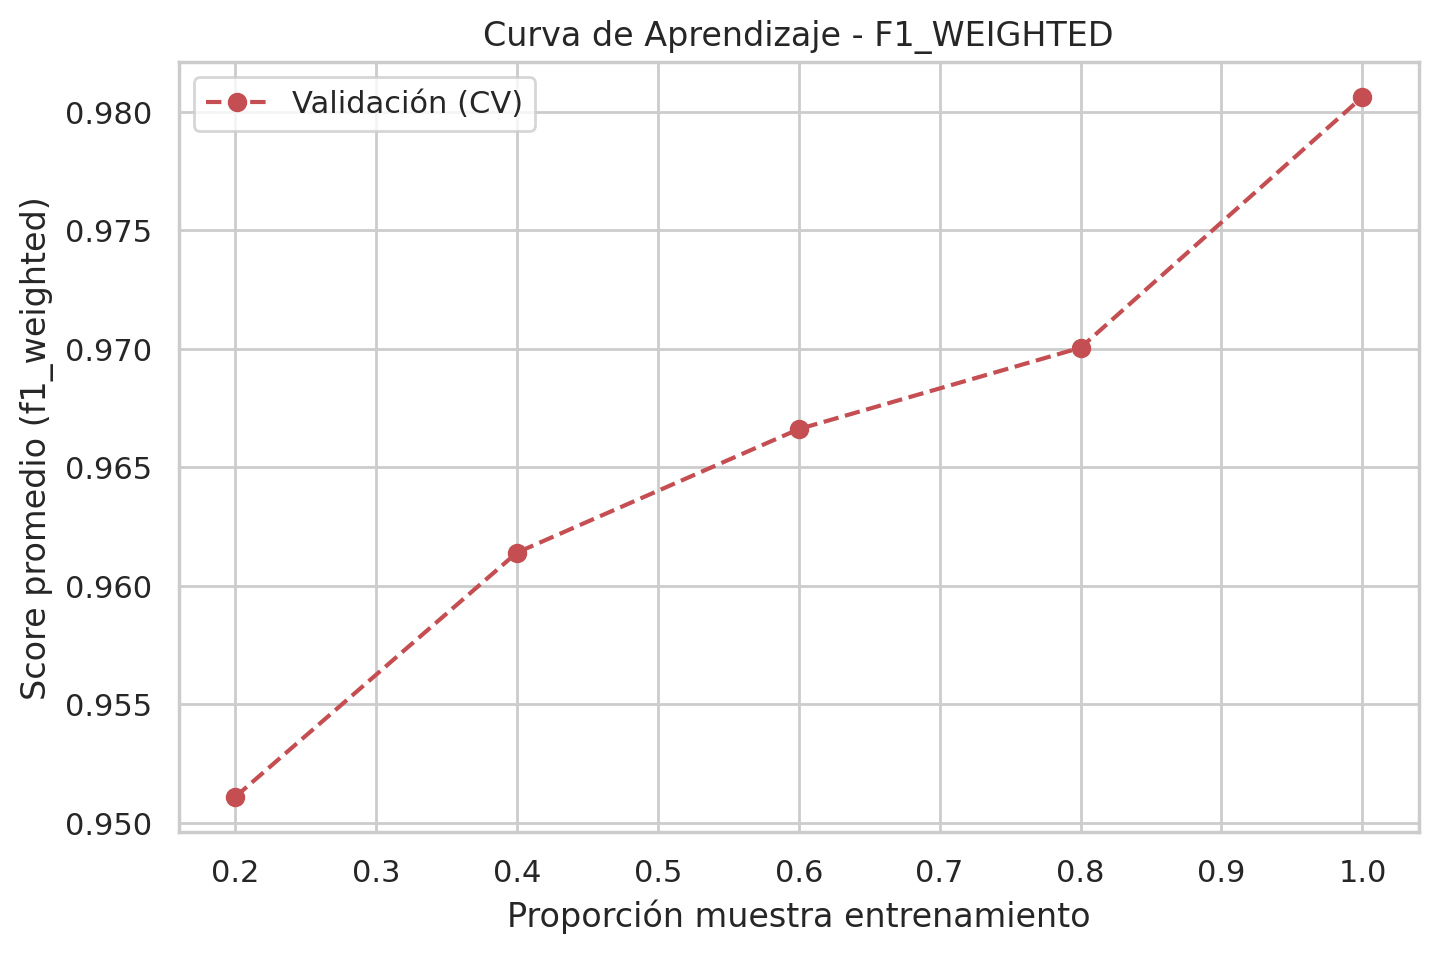

In [78]:
datos_pp, _ = preprocesar_datos(cancer, 'diagnosis')
X = datos_pp.drop('diagnosis', axis=1)
y = datos_pp['diagnosis']
curva_aprendizaje(modelo, X, y, 'f1_weighted', 10);

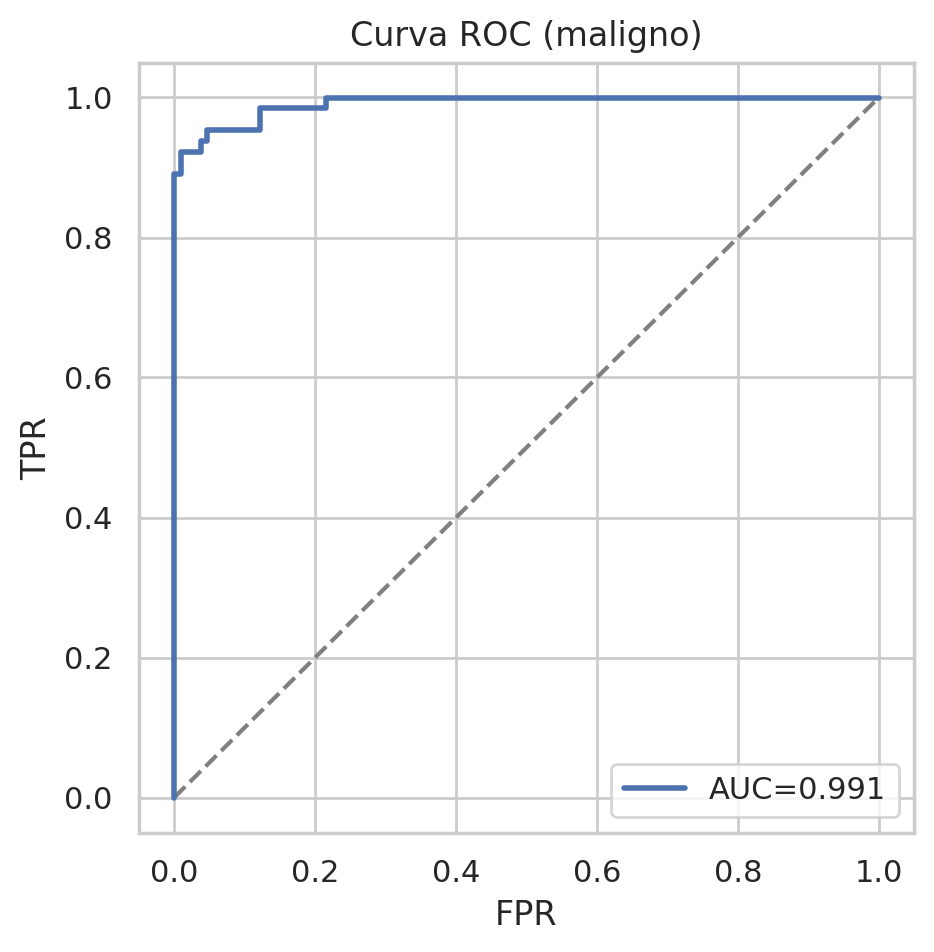

In [79]:
# ROC con decision_function (LinearSVC no da predict_proba); positivo = maligno 'M'
score_M = modelo.decision_function(xtest)
fpr, tpr, _ = roc_curve((ytest == 'M').astype(int), score_M)
auc = roc_auc_score((ytest == 'M').astype(int), score_M)
plt.figure(figsize=(5, 5)); plt.plot([0, 1], [0, 1], '--', color='gray')
plt.plot(fpr, tpr, lw=2, label=f'AUC={auc:.3f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC (maligno)')
plt.legend()
plt.show()

Pese a ser una frontera **lineal**, la SVM alcanza un recall alta (~0.9y) y un AUC próximo a 1: el problema es casi linealmente separable. Es incluso algo mejor que el k-NN sobre estos mismos datos.

### <font color="steelblue">3.1.1. Selección de variables y modelo parsimonioso</font>

Como `LinearSVC` es lineal, dispone de `coef_`, podemos aplicar `select_variables` (eliminación recursiva de variables dentro de validación cruzada) para buscar un modelo **más simple**. Exploramos un rango fino del número de variables, utilizando la métrica f1.

Calculando el ranking global de variables (puede tardar un momento)...
Evaluando combinaciones optimizando por: F1...

k óptimo (CV): 16 | F1 CV: 0.987


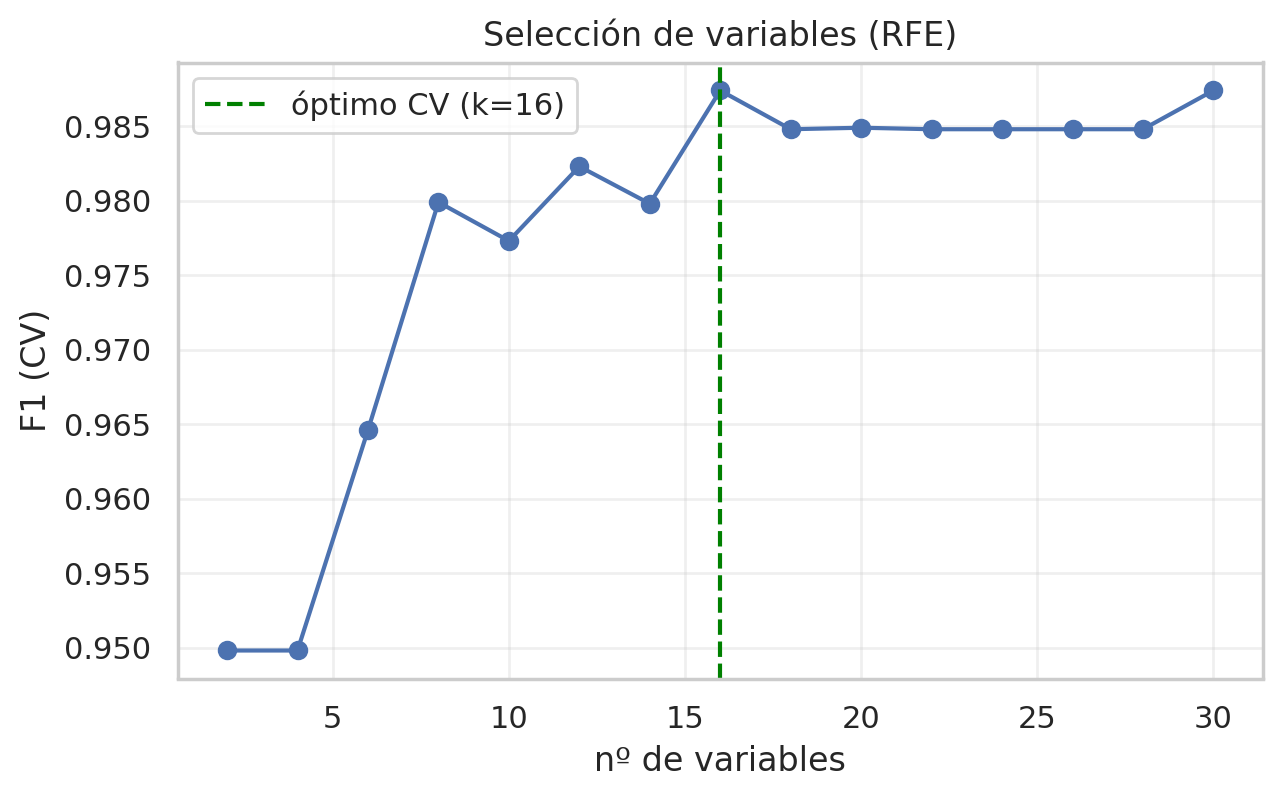

 k  accuracy     f1  recall         Nueva Variable
 2    0.9498 0.9498  0.9498   concave points_worst
 4    0.9497 0.9498  0.9497        perimeter_worst
 6    0.9648 0.9646  0.9648             area_worst
 8    0.9800 0.9799  0.9800    concave points_mean
10    0.9774 0.9773  0.9774                area_se
12    0.9825 0.9823  0.9825         compactness_se
14    0.9800 0.9798  0.9800              area_mean
16    0.9875 0.9874  0.9875           texture_mean
18    0.9849 0.9848  0.9849            symmetry_se
20    0.9849 0.9849  0.9849   fractal_dimension_se
22    0.9850 0.9848  0.9850         perimeter_mean
24    0.9850 0.9848  0.9850      concave points_se
26    0.9850 0.9848  0.9850 fractal_dimension_mean
28    0.9850 0.9848  0.9850             texture_se
30    0.9875 0.9874  0.9875      compactness_worst


In [80]:
tabla_sel, vars_opt, k_opt, score_opt = select_variables(LinearSVC(dual=False, max_iter=5000, C=gs.best_params_['C']),
                                                            xtrain, ytrain, list(range(2, 31, 2)), 'f1', 'weighted', 10)
print('k óptimo (CV):', k_opt, '| F1 CV:', round(score_opt, 3))
plt.figure(figsize=(7, 4))
plt.plot(tabla_sel.k, tabla_sel.f1, marker='o')
plt.axvline(k_opt, ls='--', color='green', label=f'óptimo CV (k={k_opt})')
plt.xlabel('nº de variables')
plt.ylabel('F1 (CV)')
plt.title('Selección de variables (RFE)')
plt.legend()
plt.grid(True, alpha=.3)
plt.show()
print(tabla_sel.round(4).to_string(index=False))

La f1 sube deprisa al principio y luego forma una **meseta**: el óptimo por validación cruzada usa muchas variables, pero la curva ya está casi plana mucho antes. Por el **principio de parsimonia**, conviene quedarse con el menor número de variables que alcance (casi) el máximo —el **codo** de la curva—, porque un modelo con menos variables es **más simple, más rápido y más interpretable**, y suele generalizar igual o mejor.

Entrenamos por tanto **tres** modelos y los comparamos: el **completo** (todas las variables), el **óptimo** según la CV ($k=k_{opt}$) y un **parsimonioso** en el codo de la curva (con k=8). Para cada subconjunto recuperamos sus variables con RFE y **ajustamos** un nuevo `LinearSVC`.

In [81]:
C = gs.best_params_['C']
k_parsi = 8   # codo de la curva: casi el máximo con muchas menos variables

def entrena_subconjunto(k):
    sel = RFE(LinearSVC(dual=False, max_iter=5000, C=C), n_features_to_select=k).fit(xtrain, ytrain)
    cols = xtrain.columns[sel.support_].tolist()
    m = LinearSVC(dual=False, max_iter=5000, C=C).fit(xtrain[cols], ytrain)
    return m, cols

modelo_opt,   vars_opt   = entrena_subconjunto(k_opt)
modelo_parsi, vars_parsi = entrena_subconjunto(k_parsi)
print(f'Modelo óptimo (k={k_opt}) entrenado. Variables:', vars_opt)
print(f'\nModelo parsimonioso (k={k_parsi}) entrenado. Variables:', vars_parsi)

Modelo óptimo (k=16) entrenado. Variables: ['radius_mean', 'texture_mean', 'area_mean', 'concave points_mean', 'radius_se', 'perimeter_se', 'area_se', 'compactness_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst']

Modelo parsimonioso (k=8) entrenado. Variables: ['concave points_mean', 'radius_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'concave points_worst']


In [82]:
comparativa = pd.DataFrame({
    'modelo': ['Completo (30)', f'Óptimo CV (k={k_opt})', f'Parsimonioso (k={k_parsi})'],
    'nº variables': [xtrain.shape[1], len(vars_opt), len(vars_parsi)],
    'exactitud_test': [accuracy_score(ytest, modelo.predict(xtest)),
                       accuracy_score(ytest, modelo_opt.predict(xtest[vars_opt])),
                       accuracy_score(ytest, modelo_parsi.predict(xtest[vars_parsi]))],
    'recall_maligno': [recall_score(ytest, modelo.predict(xtest), pos_label='M'),
                       recall_score(ytest, modelo_opt.predict(xtest[vars_opt]), pos_label='M'),
                       recall_score(ytest, modelo_parsi.predict(xtest[vars_parsi]), pos_label='M')]})
comparativa.round(3)

,modelo,nº variables,exactitud_test,recall_maligno
0,Completo (30),30,0.959,0.922
1,Óptimo CV (k=16),16,0.965,0.953
2,Parsimonioso (k=8),8,0.936,0.938


El modelo **parsimonioso** usa una fracción de las variables y mantiene un **recall maligno casi idéntico** al completo, con solo una pequeña diferencia de exactitud global. Es un excelente compromiso: a cambio de una pérdida mínima, ganamos un modelo mucho **más sencillo de interpretar y desplegar**. El modelo óptimo por CV está entre ambos. Cuál elegir depende de si priorizamos la última décima de exactitud o la simplicidad.



### <font color="steelblue">3.1.2. Equilibrado de clases</font>

La clase **maligna** es minoritaria. A diferencia del k-NN, **`LinearSVC` sí tiene `class_weight`**, así que podemos usar el **`class_weight='balanced'`** (que pondera cada clase por el inverso de su frecuencia), además del **remuestreo** (SMOTE, NearMiss). Comparamos las cuatro opciones.

In [83]:
C = gs.best_params_['C']
modelo_bal = LinearSVC(dual=False, max_iter=5000, C=C, class_weight='balanced').fit(xtrain, ytrain)
xtr_sm, ytr_sm = SMOTE(random_state=RNG).fit_resample(xtrain, ytrain)
modelo_smote = LinearSVC(dual=False, max_iter=5000, C=C).fit(xtr_sm, ytr_sm)
xtr_nm, ytr_nm = NearMiss().fit_resample(xtrain, ytrain)
modelo_nm = LinearSVC(dual=False, max_iter=5000, C=C).fit(xtr_nm, ytr_nm)
print('Tamaños — SMOTE:', ytr_sm.value_counts().to_dict(), '| NearMiss:', ytr_nm.value_counts().to_dict())

Tamaños — SMOTE: {'B': 250, 'M': 250} | NearMiss: {'B': 148, 'M': 148}


In [84]:
resumen = pd.DataFrame({'modelo': ['Base', 'class_weight=balanced', 'SMOTE', 'NearMiss'],
    'recall_maligno': [recall_score(ytest, m.predict(xtest), pos_label='M') for m in [modelo, modelo_bal, modelo_smote, modelo_nm]],
    'exactitud': [accuracy_score(ytest, m.predict(xtest)) for m in [modelo, modelo_bal, modelo_smote, modelo_nm]]})
resumen.round(3)

,modelo,recall_maligno,exactitud
0,Base,0.922,0.959
1,class_weight=balanced,0.938,0.947
2,SMOTE,0.922,0.947
3,NearMiss,0.938,0.959


¿Cómo interpretamos los resultados?

## <font color="steelblue">3.2. Abalones (3 clases)</font>

Clasificamos el **sexo** (M/F/I) de los abalones a partir de medidas morfométricas. Es un problema **difícil**: machos y hembras adultos son casi indistinguibles.

In [85]:
url = 'https://raw.githubusercontent.com/ia4legos/MachineLearning/main/data/abalone_clean.csv'
abalone = pd.read_csv(url, index_col=0)
abalone['Sex'] = abalone['Sex'].astype('category')

Preprocesamos y dividimos.

In [86]:
strain_raw, stest_raw = split_sample(abalone, 'Sex', 0.3, 0, True)
strain, prep = preprocesar_datos(strain_raw, 'Sex')
stest,  _    = preprocesar_datos(stest_raw,  'Sex', prep)
xtrain, ytrain = strain.drop('Sex', axis=1), strain['Sex']
xtest,  ytest  = stest.drop('Sex', axis=1),  stest['Sex']

Estratificando por 'Sex'.
  Entrenamiento: 2923 muestras | Test: 1254 muestras


Mejor C: {'C': 1} | acc CV: 0.55


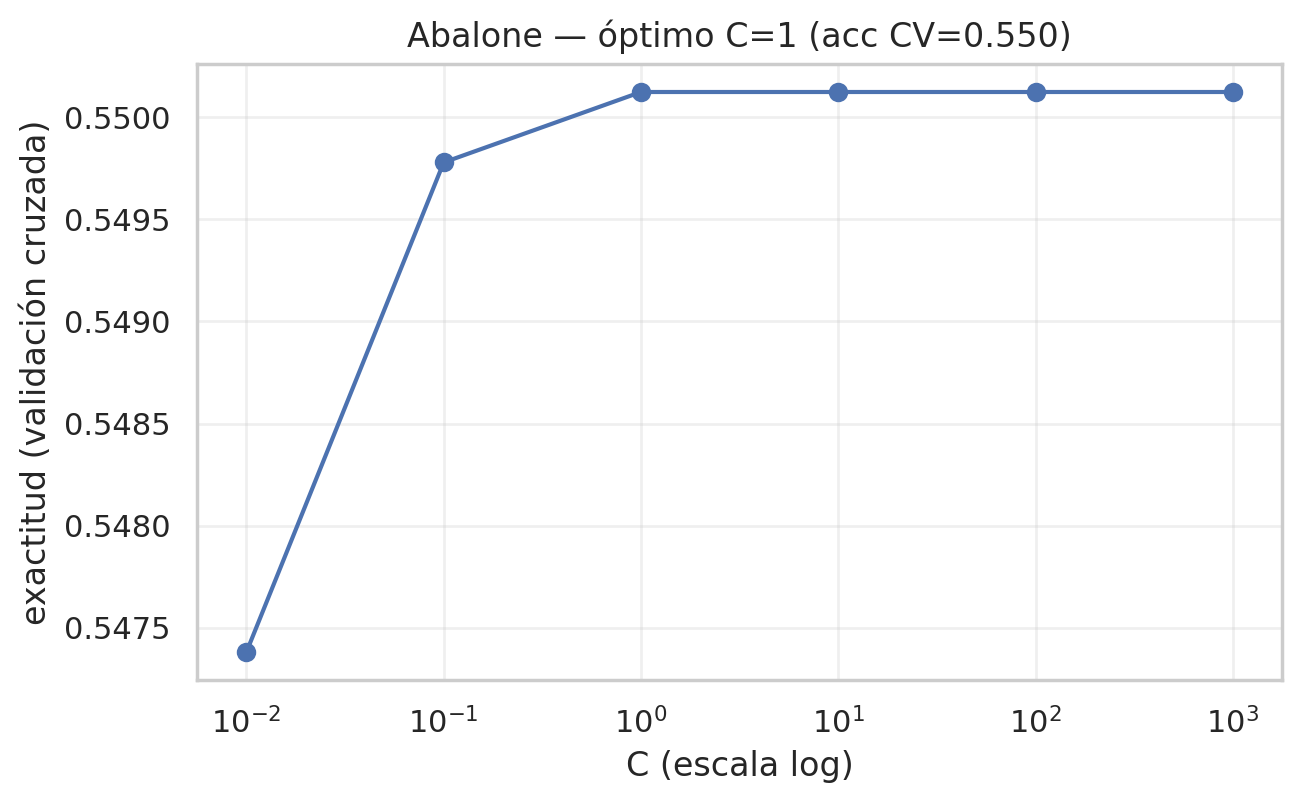

In [87]:
gs = GridSearchCV(LinearSVC(dual=False, max_iter=5000), pgrid, scoring='accuracy', cv=KFold(5))
gs.fit(xtrain, ytrain)
print('Mejor C:', gs.best_params_, '| acc CV:', round(gs.best_score_, 3))
cv_C(gs, 'Abalone')

In [88]:
modelo = gs.best_estimator_
reports_clas(modelo, xtrain, ytrain, xtest, ytest)

Métricas de clasificación en la muestra de entrenamiento
              precision    recall  f1-score   support

           F       0.51      0.41      0.45       915
           I       0.64      0.84      0.73       939
           M       0.50      0.44      0.47      1069

    accuracy                           0.56      2923
   macro avg       0.55      0.57      0.55      2923
weighted avg       0.55      0.56      0.55      2923


 Métricas de clasificación en la muestra test
              precision    recall  f1-score   support

           F       0.45      0.35      0.39       392
           I       0.63      0.84      0.72       403
           M       0.50      0.45      0.47       459

    accuracy                           0.54      1254
   macro avg       0.53      0.55      0.53      1254
weighted avg       0.53      0.54      0.53      1254



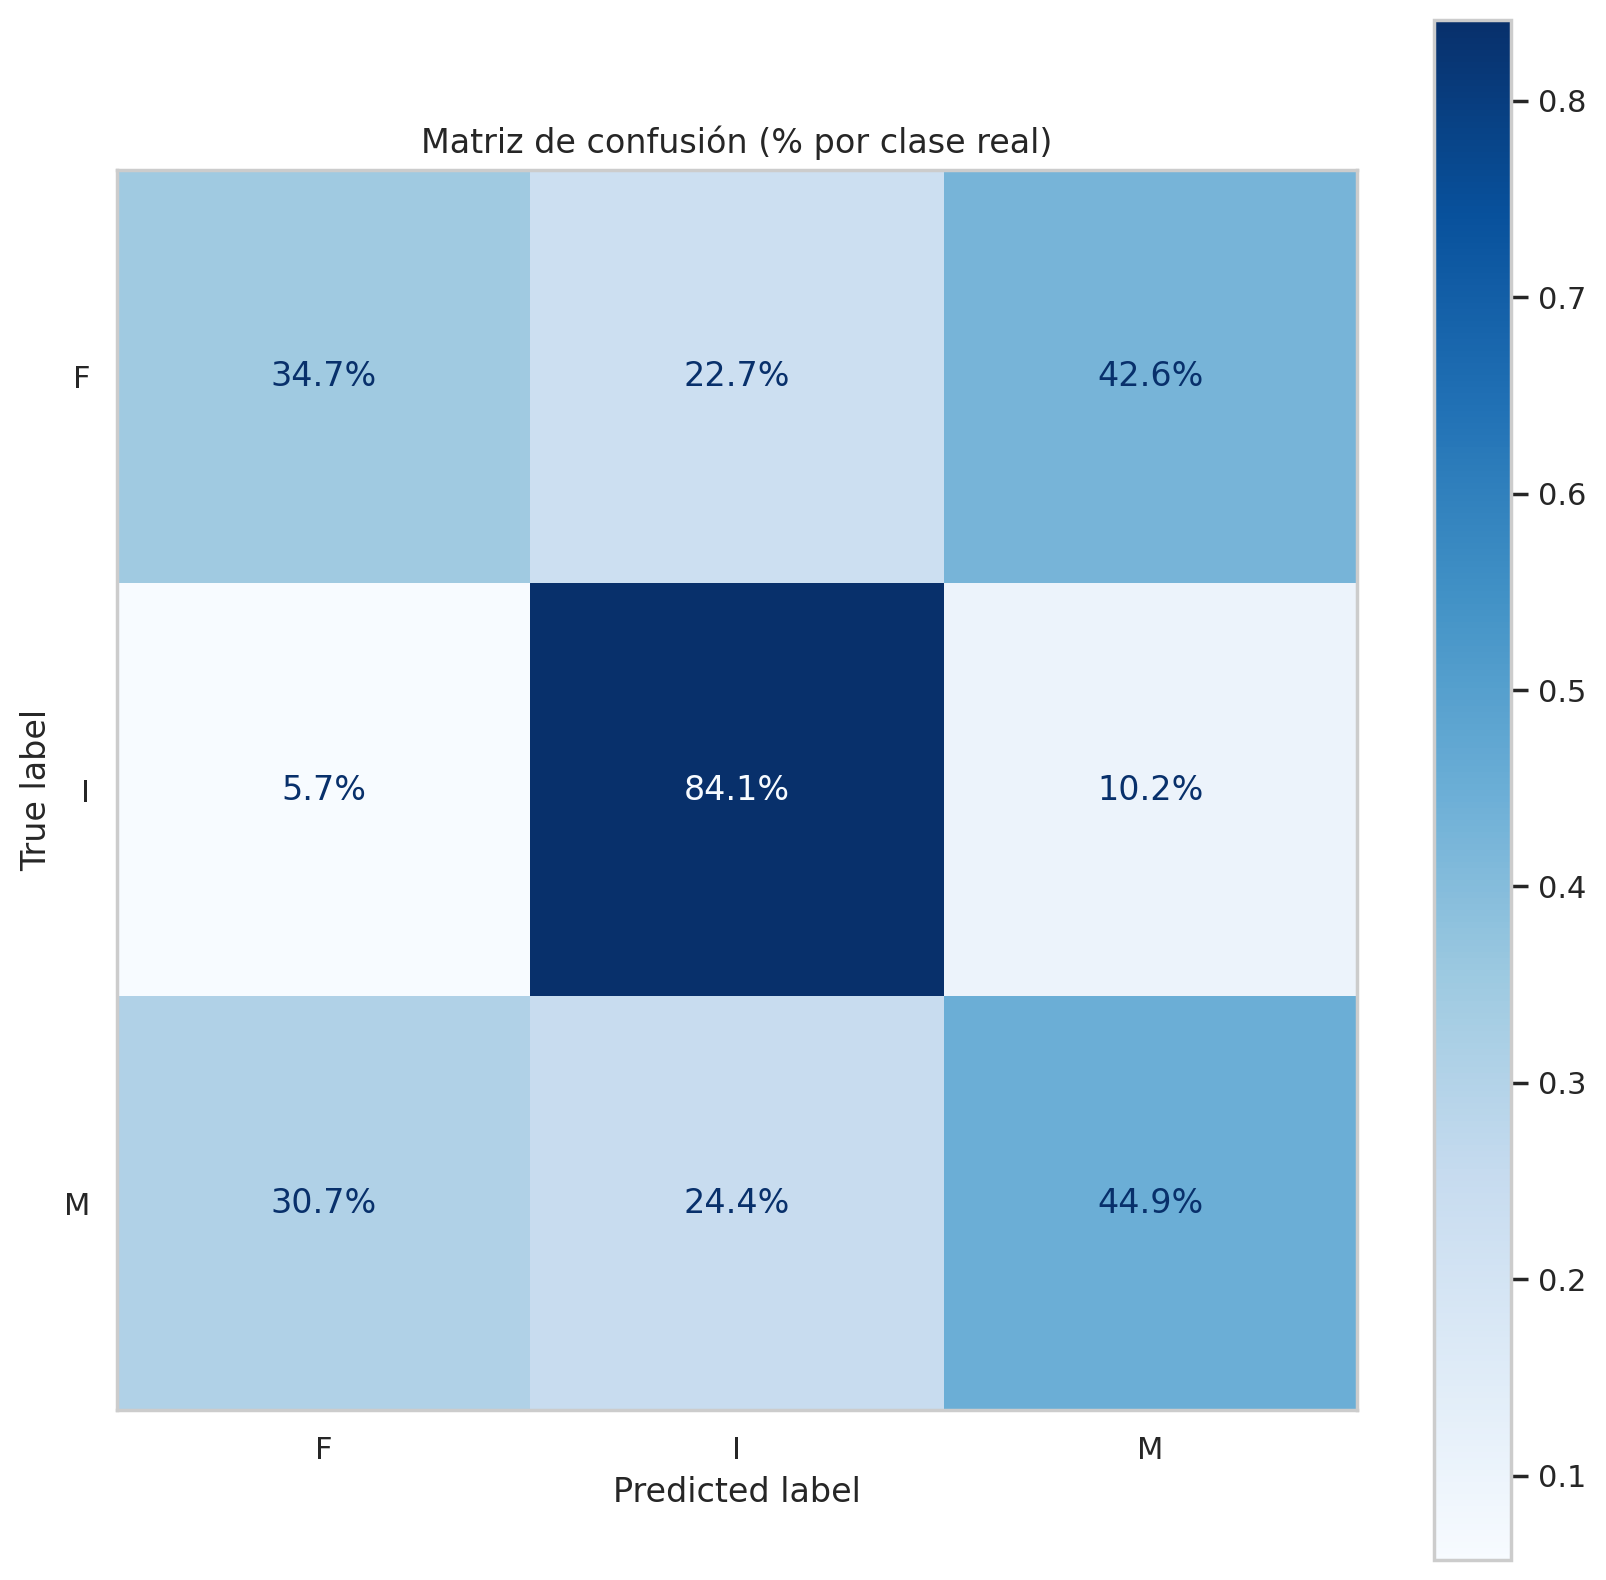

In [89]:
matriz_confusion(modelo, xtest, ytest);

In [90]:
val = validar_modelo(modelo, xtrain, ytrain, 'accuracy', 10)

Validacion cruzada (10 folds, score=accuracy): media = 0.553 +/- 0.016


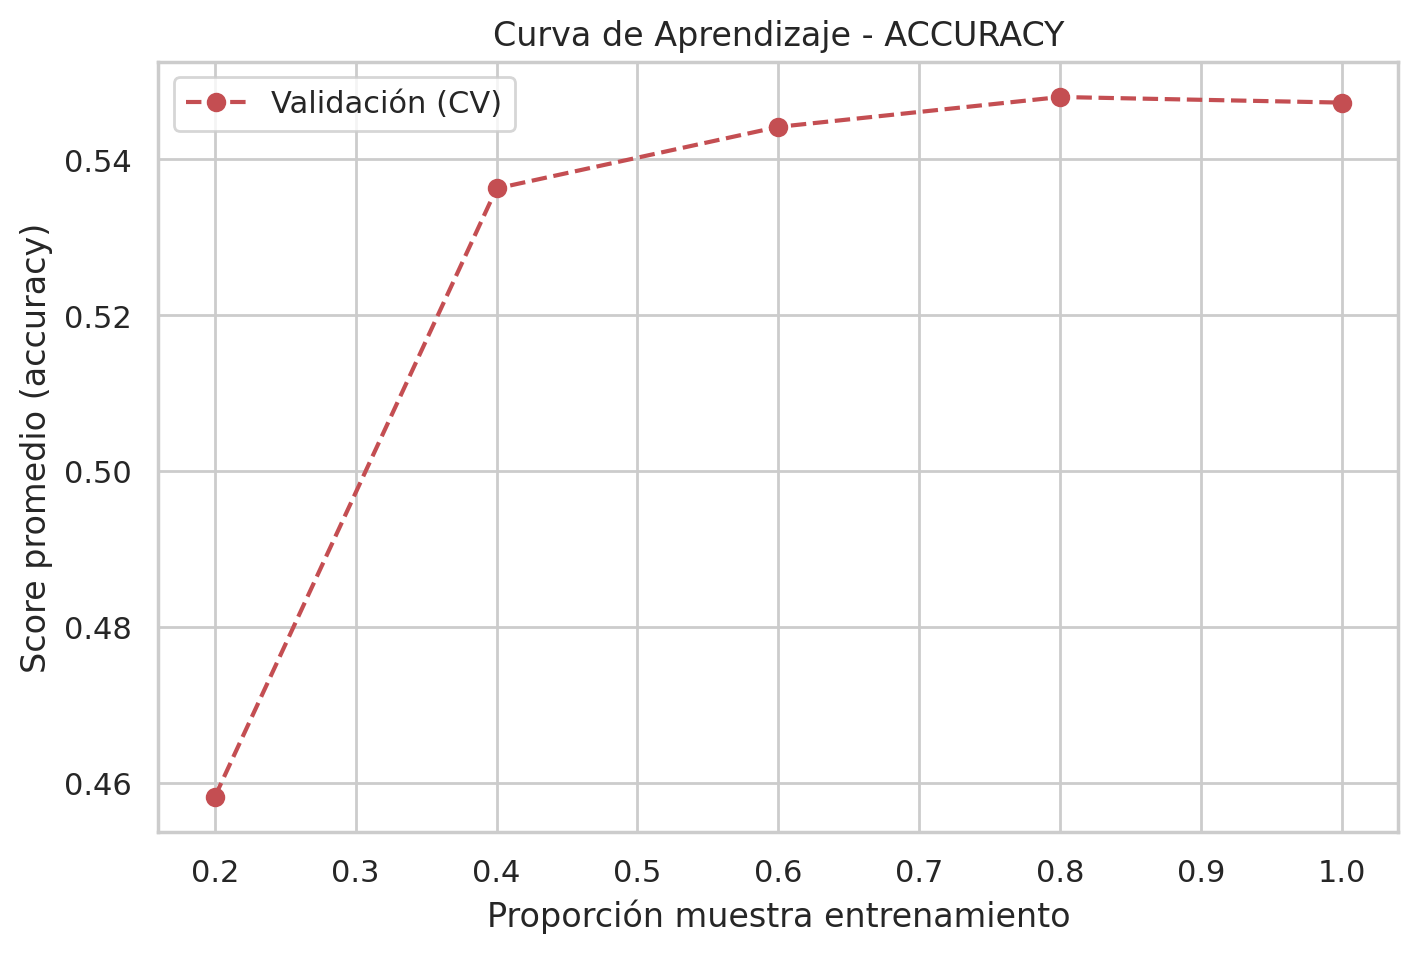

In [91]:
datos_pp, _ = preprocesar_datos(abalone, 'Sex')
X = datos_pp.drop('Sex', axis=1)
y = datos_pp['Sex']
curva_aprendizaje(modelo, X, y, 'accuracy', 10);

La exactitud ronda el **0.54**: la matriz de confusión muestra que **I** se reconoce bien pero **M y F se confunden mucho**. Es **dificultad del problema** (las clases no son linealmente separables con estas variables), no falta de ajuste. Como las clases están **casi equilibradas**, el equilibrado no es necesario aquí; la vía de mejora sería redefinir el objetivo (adulto vs. juvenil) o usar fronteras **no lineales** (kernels, cuaderno siguiente).




# <font color="steelblue">4. Referencias</font>

* James, Witten, Hastie & Tibshirani (2021). *An Introduction to Statistical Learning* (cap. 9). Springer.
* Hastie, Tibshirani & Friedman (2009). *The Elements of Statistical Learning* (cap. 12).
* Kowalczyk, A. (2017). *Support Vector Machines Succinctly*. Syncfusion.
* Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*. O'Reilly.
* scikit-learn — *Support Vector Machines*: https://scikit-learn.org/stable/modules/svm.html